In [117]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install ipywidgets
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Premier League Referee Analytics

## Goal
Analyze referee behavior across multiple Premier League seasons.

Questions:
- Which referees are strictest?
- Which referees favor home/away teams?
- Which referees are most consistent?
- Can referees be grouped into different officiating styles?

In [118]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# from scipy.stats import zscore

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/total_games.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# individual referee statistics for ml later?
referee_stats = df.groupby("referee").agg({
    "total_fouls": ["mean", "std", "median"],
    "total_yellows": ["mean", "std"],
    "home_yellow": "mean",
    "away_yellow": "mean" })
print(referee_stats.head(10))




# df.head()# df.head()

               total_fouls                  total_yellows            \
                      mean       std median          mean       std   
referee                                                               
A Kitchen        24.500000  2.588436   25.0      3.166667  1.169045   
A Madley         22.875000  5.867919   22.0      3.681818  2.525937   
A Marriner       19.153846  3.975889   19.0      3.538462  1.898042   
A Taylor         20.703390  5.033748   20.0      3.813559  2.392828   
Andre Marriner   22.114754  5.263623   22.0      2.778689  1.698382   
Andy Madley      27.304348  6.051151   27.5      2.782609  1.999034   
Anthony Taylor   24.455782  6.135715   24.0      3.442177  2.074401   
C Kavanagh       21.620690  4.946790   22.0      3.816092  2.180936   
C Pawson         22.542169  4.934451   22.0      3.746988  2.157479   
Chris Kavanagh   25.314286  5.447855   26.0      3.352381  1.985432   

               home_yellow away_yellow  
                      mean        m

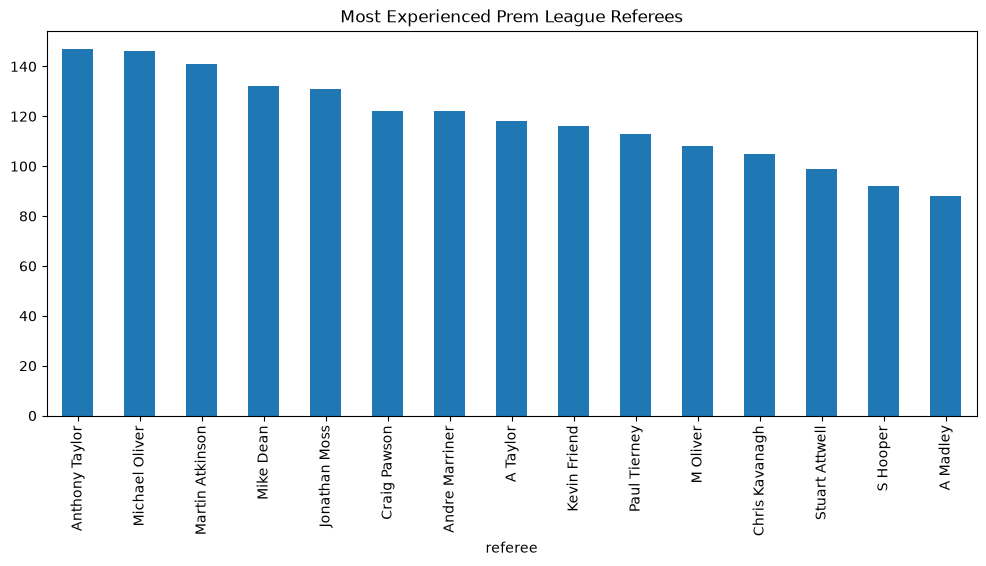

In [119]:
# Most experienced referees
ref_games = df["referee"].value_counts()
ref_games.head(15).plot(kind="bar", figsize=(12,5), title="Most Experienced Prem League Referees")
plt.show()

## Strictness Score

Measures how likely a referee is to give a yellow card once a foul has been called.

Higher values indicate referees who are quicker to issue cautions.

<Axes: title={'center': 'Most Strict Referees (Card per Foul)'}, xlabel='referee'>

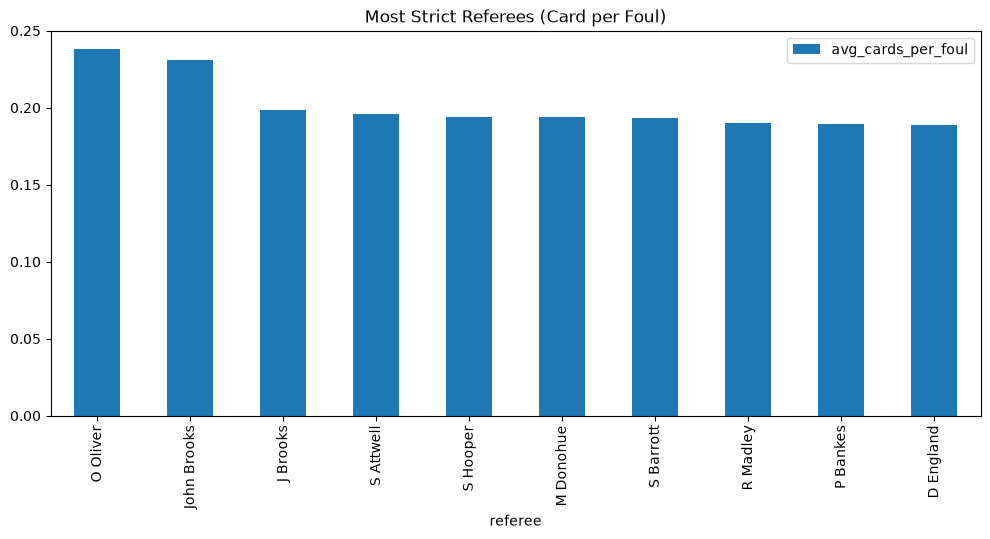

In [120]:
#dont divide by 0
df["card_per_foul"] = np.where(df["total_fouls"] > 0, df["total_yellows"] / df["total_fouls"], np.nan)

strictness = (
    df.groupby("referee")
        .agg(
            games=("referee", "count"),
            avg_cards_per_foul=("card_per_foul", "mean"),
            avg_fouls=("total_fouls", "mean"),
            avg_yellows=("total_yellows", "mean")
        )
        .sort_values("avg_cards_per_foul", ascending=False)
)

strictness.head(10).plot(kind="bar", y="avg_cards_per_foul", figsize=(12,5), title="Most Strict Referees (Card per Foul)")

## Consistency

Standard deviation measures how much a referee's card count changes from game to game.

Lower values indicate more predictable officiating.

In [121]:
consistency = (
    df.groupby("referee")
        .agg(
            games=("referee", "count"),
            yellow_std=("total_yellows", "std"),
            foul_std=("total_fouls", "std")
        )
)

# Combined consistency percentile based on both fouls and yellow cards
yellow_rank = consistency["yellow_std"].rank(pct=True)
foul_rank = consistency["foul_std"].rank(pct=True)

consistency["composite_consistency"] = 100 - ((yellow_rank + foul_rank) / 2 * 100)

consistency = consistency.sort_values("composite_consistency", ascending=False)
consistency.head()

,games,yellow_std,foul_std,composite_consistency
referee,,,,
D Webb,2,0.707107,2.121320,96.666667
A Kitchen,6,1.169045,2.588436,94.166667
Robert Jones,22,1.255292,3.659773,92.500000
T Harrington,45,1.718879,3.691650,85.833333
Niel Swarbrick,20,1.490320,4.897905,77.500000


## Career Trend

Measure whether referees have become stricter or more lenient over time.

In [122]:
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib.dates as mdates

# make sure date is a real datetime, not a string
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["referee", "date"])

df["rolling_yellows"] = (
    df.groupby("referee")["total_yellows"]
        .transform(lambda x: x.rolling(10, min_periods=1).mean())
)

df["rolling_fouls"] = (
    df.groupby("referee")["total_fouls"]
        .transform(lambda x: x.rolling(10, min_periods=1).mean())
)

referees = sorted(df["referee"].dropna().unique())

def plot_referee_trend(ref_name, df=df):
    ref_df = df[df["referee"] == ref_name].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 5))

    marker = "o" if len(ref_df) < 60 else None
    ax.plot(ref_df["date"], ref_df["rolling_yellows"], label="Rolling Yellows (10-game)", marker=marker, markersize=3)
    ax.plot(ref_df["date"], ref_df["rolling_fouls"], label="Rolling Fouls (10-game)", marker=marker, markersize=3)

    ax.set_title(f"Career Trend: {ref_name} ({len(ref_df)} games)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling Average")
    ax.legend()

    # auto-pick sensible tick spacing instead of labeling every match date
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    plt.tight_layout()
    plt.show()

@interact(ref_name=widgets.Dropdown(options=referees, description="Referee:"))
def explore(ref_name):
    plot_referee_trend(ref_name)


interactive(children=(Dropdown(description='Referee:', options=('A Kitchen', 'A Madley', 'A Marriner', 'A Tayl…

## Team–Referee Interaction

Average yellow cards received by each team under each referee.

In [123]:
home = df[["referee", "home_team", "home_yellow"]].rename(
    columns={"home_team": "team", "home_yellow": "yellow"}
)

away = df[["referee", "away_team", "away_yellow"]].rename(
    columns={"away_team": "team", "away_yellow": "yellow"}
)

team_cards = pd.concat([home, away], ignore_index=True)

team_ref_matrix = team_cards.pivot_table(
    index="team",
    columns="referee",
    values="yellow",
    aggfunc="mean"
)

team_ref_matrix.head()

referee,A Kitchen,A Madley,A Marriner,A Taylor,Andre Marriner,Andy Madley,Anthony Taylor,C Kavanagh,C Pawson,Chris Kavanagh,Craig Pawson,D Bond,D Coote,D England,D Webb,Darren England,David Coote,F Hallam,G Scott,Graham Scott,J Brooks,J Gillett,J Smith,Jarred Gillett,John Brooks,Jonathan Moss,K Kavanagh,Kevin Friend,L Smith,Lee Mason,Lee Probert,M Donohue,M Oliver,M Salisbury,Martin Atkinson,Michael Oliver,Michael Salisbury,Mike Dean,Mike Jones,Niel Swarbrick,O Oliver,Oliver Langford,P Bankes,P Tierney,Paul Tierney,Peter Bankes,R Jones,R Madley,R Welch,Robert Jones,Robert Madley,Roger East,S Allison,S Attwell,S Barrott,S Hooper,S Singh,Simon Hooper,Stuart Attwell,T Bramall,T Harrington,T Kirk,T Robinson,Tim Robinson,Tony Harrington
team,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Arsenal,NaN,1.500000,0.0,2.222222,1.214286,3.0,1.526316,2.000000,1.000000,1.769231,2.000000,0.000000,1.714286,1.000000,NaN,3.000000,1.000000,1.0,NaN,1.333333,1.833333,1.222222,1.0,2.0,NaN,1.928571,NaN,2.222222,NaN,1.333333,0.00,NaN,1.555556,1.000000,1.444444,2.000000,NaN,2.062500,NaN,1.0,NaN,NaN,1.333333,1.555556,2.636364,1.000000,1.285714,NaN,NaN,NaN,1.5,NaN,NaN,1.000000,1.250000,1.833333,NaN,NaN,2.416667,0.000,0.000000,NaN,0.666667,NaN,NaN
Aston Villa,3.0,2.500000,NaN,2.090909,NaN,2.0,2.800000,2.166667,1.900000,1.700000,2.363636,2.500000,2.875000,2.333333,NaN,2.333333,1.666667,NaN,0.0,2.000000,2.857143,1.818182,NaN,2.0,4.5,1.571429,NaN,7.000000,2.0,0.666667,NaN,NaN,1.900000,1.600000,1.666667,1.750000,3.0,2.666667,NaN,NaN,NaN,NaN,2.000000,0.800000,1.714286,2.000000,1.500000,NaN,NaN,0.5,NaN,NaN,NaN,2.600000,1.142857,1.555556,NaN,1.500000,2.166667,2.250,2.000000,NaN,1.750000,NaN,NaN
Bournemouth,NaN,2.000000,4.0,2.500000,1.250000,0.0,1.500000,1.428571,2.000000,1.571429,1.666667,2.000000,2.500000,2.500000,NaN,NaN,1.000000,NaN,1.5,1.714286,2.000000,2.666667,NaN,NaN,NaN,2.000000,NaN,1.777778,0.0,1.428571,1.25,2.000000,1.888889,2.090909,1.428571,2.333333,NaN,2.444444,1.0,NaN,3.0,NaN,1.888889,2.250000,1.777778,3.000000,2.125000,2.0,3.0,NaN,2.0,1.571429,1.0,2.444444,2.000000,2.000000,NaN,2.333333,2.375000,2.875,3.333333,NaN,2.333333,NaN,NaN
Brentford,NaN,1.900000,2.0,1.000000,0.000000,0.0,3.000000,1.500000,1.666667,0.000000,2.000000,1.833333,3.000000,2.111111,NaN,2.800000,1.500000,0.0,1.0,3.000000,1.875000,1.250000,3.5,2.0,NaN,0.750000,NaN,NaN,1.0,NaN,NaN,2.666667,1.500000,2.400000,1.000000,2.333333,0.0,3.000000,NaN,NaN,NaN,NaN,1.615385,1.400000,3.000000,2.666667,2.400000,2.0,NaN,2.0,NaN,NaN,NaN,1.444444,1.750000,2.545455,NaN,1.000000,1.000000,1.500,1.000000,NaN,2.500000,NaN,NaN
Brighton,NaN,2.222222,2.5,1.750000,NaN,NaN,NaN,2.428571,2.000000,NaN,NaN,1.000000,2.400000,2.250000,NaN,NaN,NaN,NaN,1.0,NaN,2.000000,2.166667,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.200000,2.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,1.600000,NaN,NaN,2.200000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.857143,2.181818,NaN,NaN,NaN,2.000,1.400000,2.0,2.500000,NaN,NaN


## League Percentiles

Rank each referee relative to every other referee.

In [124]:
referee_profiles = (
    df.groupby("referee")
        .agg(
            games=("referee", "count"),
            avg_fouls=("total_fouls", "mean"),
            avg_yellows=("total_yellows", "mean"),
            avg_cards_per_foul=("card_per_foul", "mean"),
            yellow_std=("total_yellows", "std"),
            foul_std=("total_fouls", "std")
        )
)

referee_profiles["strictness_pct"] = (
    referee_profiles["avg_cards_per_foul"]
    .rank(pct=True) * 100
)

referee_profiles["consistency_pct"] = (
    100 -
    referee_profiles["yellow_std"].rank(pct=True) * 100
)

referee_profiles.head()

,games,avg_fouls,avg_yellows,avg_cards_per_foul,yellow_std,foul_std,strictness_pct,consistency_pct
referee,,,,,,,,
A Kitchen,6,24.500000,3.166667,0.133749,1.169045,2.588436,27.692308,93.333333
A Madley,88,22.875000,3.681818,0.157929,2.525937,5.867919,53.846154,3.333333
A Marriner,13,19.153846,3.538462,0.184370,1.898042,3.975889,81.538462,66.666667
A Taylor,118,20.703390,3.813559,0.185560,2.392828,5.033748,83.076923,5.000000
Andre Marriner,122,22.114754,2.778689,0.127841,1.698382,5.263623,21.538462,81.666667


In [125]:
referee_profiles.to_csv("../data/referee_profiles.csv")
team_ref_matrix.to_csv("../data/team_referee_matrix.csv")
df[["referee", "date", "total_fouls", "total_yellows", "rolling_yellows", "rolling_fouls"]].to_csv(
    "../data/referee_game_log.csv", index=False
)

## Clutering

Referree archetypes, unsupervised ml

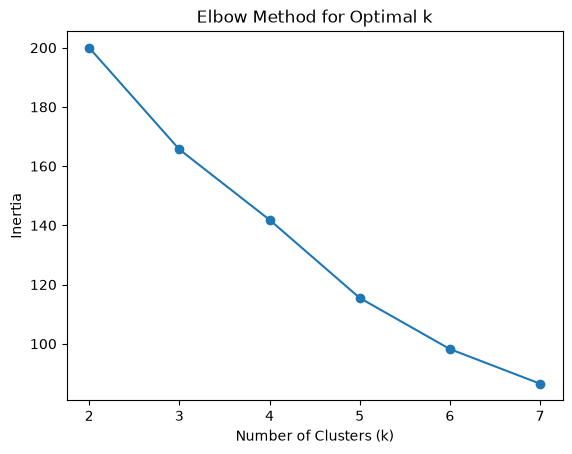

--- Silhouette Scores ---
k = 2: Silhouette Score = 0.3241
k = 3: Silhouette Score = 0.2756
k = 4: Silhouette Score = 0.2816
k = 5: Silhouette Score = 0.3076
k = 6: Silhouette Score = 0.2939
k = 7: Silhouette Score = 0.2905


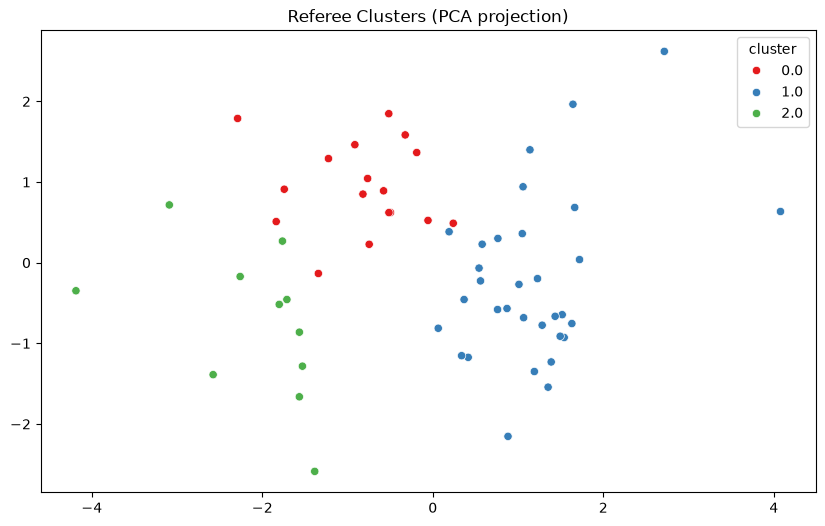


--- Cluster 0 (17 referees) ---
Andy Madley, Anthony Taylor, Chris Kavanagh, Craig Pawson, David Coote, Jonathan Moss, Kevin Friend, Martin Atkinson, Michael Oliver, Mike Jones, Paul Tierney, Peter Bankes, R Welch, Robert Madley, Simon Hooper, Stuart Attwell, T Kirk

--- Cluster 1 (32 referees) ---
A Madley, A Marriner, A Taylor, C Kavanagh, C Pawson, D Bond, D Coote, D England, Darren England, J Brooks, J Gillett, J Smith, Jarred Gillett, John Brooks, L Smith, M Donohue, M Oliver, M Salisbury, Michael Salisbury, Mike Dean, P Bankes, P Tierney, R Jones, R Madley, Roger East, S Allison, S Attwell, S Barrott, S Hooper, T Bramall, T Harrington, T Robinson

--- Cluster 2 (11 referees) ---
A Kitchen, Andre Marriner, D Webb, F Hallam, G Scott, Graham Scott, Lee Mason, Lee Probert, Niel Swarbrick, Robert Jones, Tony Harrington


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

#select features for clustering + scale them

cluster_features = ["avg_fouls", "avg_yellows", "avg_cards_per_foul", "yellow_std", "foul_std"]
x_cluster = referee_profiles[cluster_features].dropna()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

# find reasonable k with elbow method

intertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    intertias.append(km.inertia_)

# plot the elbow curve
plt.plot(k_range, intertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# 4 calculate sillhousette scores
print("--- Silhouette Scores ---")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f"k = {k}: Silhouette Score = {score:.4f}")

# fit final model with k=3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
referee_profiles.loc[x_cluster.index, "cluster"] = kmeans.fit_predict(x_scaled)

# visualize clusters
pca = PCA(n_components=2)
components = pca.fit_transform(x_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=referee_profiles.loc[x_cluster.index, "cluster"], palette="Set1")
plt.title("Referee Clusters (PCA projection)")
plt.show()

referee_profiles.groupby("cluster")[cluster_features].mean()

referee_profiles.to_csv("../data/referee_profiles.csv", index=False)

for cluster, group in referee_profiles.groupby("cluster"):
    print(f"\n--- Cluster {int(cluster)} ({len(group)} referees) ---")
    print(", ".join(group.index))

## Regression: Predict total yellows for a matchup

In [127]:
import pandas as pd
import numpy as np

# --- build team historical features (rolling instead of full-career expanding) ---

df = df.sort_values("date").reset_index(drop=True)

ROLL_WINDOW = 10  # last N games — tune this

home = df[["date", "home_team", "home_yellow", "total_fouls"]].rename(
    columns={"home_team": "team", "home_yellow": "yellow"}
)
away = df[["date", "away_team", "away_yellow", "total_fouls"]].rename(
    columns={"away_team": "team", "away_yellow": "yellow"}
)
team_history = pd.concat([home, away]).sort_values(["team", "date"])

# shifted rolling mean so only prior games are used (no leakage)
team_history["team_avg_yellow_hist"] = (
    team_history.groupby("team")["yellow"]
    .transform(lambda x: x.shift(1).rolling(ROLL_WINDOW, min_periods=3).mean())
)
team_history["team_avg_foul_hist"] = (
    team_history.groupby("team")["total_fouls"]
    .transform(lambda x: x.shift(1).rolling(ROLL_WINDOW, min_periods=3).mean())
)

home_hist = team_history.rename(columns={
    "team": "home_team",
    "team_avg_yellow_hist": "home_team_hist",
    "team_avg_foul_hist": "home_team_foul_hist"
})
away_hist = team_history.rename(columns={
    "team": "away_team",
    "team_avg_yellow_hist": "away_team_hist",
    "team_avg_foul_hist": "away_team_foul_hist"
})

df = df.merge(home_hist[["date", "home_team", "home_team_hist", "home_team_foul_hist"]],
              on=["date", "home_team"], how="left")
df = df.merge(away_hist[["date", "away_team", "away_team_hist", "away_team_foul_hist"]],
              on=["date", "away_team"], how="left")

# --- referee features: split the composite ratio back into its parts ---
ref_feats = referee_profiles[["avg_cards_per_foul", "avg_yellows", "yellow_std"]]
df = df.merge(ref_feats, left_on="referee", right_index=True, how="left")
df = df.rename(columns={
    "avg_cards_per_foul": "ref_strictness",
    "avg_yellows": "ref_avg_yellows",
    "yellow_std": "ref_yellow_std"
})

# --- team identity as categorical (captures rivalry / high-intensity fixtures) ---
df["home_team_cat"] = df["home_team"].astype("category").cat.codes
df["away_team_cat"] = df["away_team"].astype("category").cat.codes

# --- build training table ---
features = [
    "home_team_hist", "away_team_hist",
    "home_team_foul_hist", "away_team_foul_hist",
    "ref_strictness", "ref_avg_yellows", "ref_yellow_std",
]
target = "total_yellows"

model_df = df.dropna(subset=features + [target]).copy()
x = model_df[features]
y = model_df[target]

# --- baseline: what MAE/R2 do you get from just guessing the mean? ---
baseline_pred = np.full_like(y, y.mean(), dtype=float)
print(f"Baseline (predict mean): MAE={np.mean(np.abs(y - baseline_pred)):.2f}, "
      f"y std={y.std():.2f}")

# --- time-series cross-validation instead of one fixed split ---
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42
    )
}

for name, model in models.items():
    maes, r2s = [], []
    for train_idx, test_idx in tscv.split(x):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))
    print(f"{name}: MAE={np.mean(maes):.2f} (+/-{np.std(maes):.2f}), "
          f"R2={np.mean(r2s):.3f} (+/-{np.std(r2s):.3f})")

rf_simple = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=20,
    random_state=42
)

maes, r2s = [], []

for train_idx, test_idx in tscv.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_simple.fit(x_train, y_train)
    preds = rf_simple.predict(x_test)

    maes.append(mean_absolute_error(y_test, preds))
    r2s.append(r2_score(y_test, preds))

print(f"Simple Random Forest: MAE={np.mean(maes):.2f} (+/-{np.std(maes):.2f}), "
      f"R2={np.mean(r2s):.3f} (+/-{np.std(r2s):.3f})")


Baseline (predict mean): MAE=1.67, y std=2.06
Linear Regression: MAE=1.60 (+/-0.04), R2=0.031 (+/-0.026)
Random Forest: MAE=1.63 (+/-0.05), R2=-0.008 (+/-0.046)
Simple Random Forest: MAE=1.61 (+/-0.05), R2=0.013 (+/-0.032)


In [128]:
# --- add referee × team interaction features ---

model_df["ref_x_home_fouls"] = (
    model_df["ref_strictness"] * model_df["home_team_foul_hist"]
)

model_df["ref_x_away_fouls"] = (
    model_df["ref_strictness"] * model_df["away_team_foul_hist"]
)

# Original features + interaction features
features_v2 = features + [
    "ref_x_home_fouls",
    "ref_x_away_fouls"
]

x2 = model_df[features_v2]

print("Added interaction features:")
print("- ref_x_home_fouls")
print("- ref_x_away_fouls")

Added interaction features:
- ref_x_home_fouls
- ref_x_away_fouls


In [130]:
# --- evaluate models with interaction features ---

for name, model in models.items():
    maes, r2s = [], []

    for train_idx, test_idx in tscv.split(x2):
        x_train, x_test = x2.iloc[train_idx], x2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(x_train, y_train)
        preds = model.predict(x_test)

        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))

    print(
        f"{name} + interactions: "
        f"MAE={np.mean(maes):.2f} (+/-{np.std(maes):.2f}), "
        f"R2={np.mean(r2s):.3f} (+/-{np.std(r2s):.3f})"
    )

df["season"] = df["date"].dt.year

season_stats = (
    df.groupby("season")["total_yellows"]
      .agg(["mean", "std", "count"])
)

print(season_stats)

Linear Regression + interactions: MAE=1.60 (+/-0.05), R2=0.028 (+/-0.030)
Random Forest + interactions: MAE=1.64 (+/-0.03), R2=-0.020 (+/-0.024)
            mean       std  count
season                           
2017    3.339713  2.306846    209
2018    3.234501  1.988207    371
2019    3.564644  2.003414    379
2020    3.184524  2.004889    336
2021    3.323529  1.946012    408
2022    3.415512  2.005321    361
2023    4.043689  2.094608    412
2024    4.196237  2.137254    372
2025    3.624339  2.089925    378
2026    3.814433  1.825722    194
